In [ ]:
Part1-Understanding the Data and Visualization

In [ ]:
import os

# Explore one participant folder
participant = "/content/drive/MyDrive/AP01"

for f in os.listdir(participant):
    print(f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Flow - 30-05-2024.txt
SPO2 - 30-05-2024.txt
Sleep profile - 30-05-2024.txt
Flow Events - 30-05-2024.txt
Thorac - 30-05-2024.txt


In [ ]:
import pandas as pd

base = "/content/drive/MyDrive/AP01"

# List all files

for f in os.listdir(base):
    print(f)


for f in os.listdir(base):
    path = os.path.join(base, f)
    try:
        df = pd.read_csv(path, nrows=3)
        print(f"\n--- {f} ---")
        print(df)
    except:
        print(f"\n--- {f} --- (not a CSV or unreadable)")


Flow - 30-05-2024.txt
SPO2 - 30-05-2024.txt
Sleep profile - 30-05-2024.txt
Flow Events - 30-05-2024.txt
Thorac - 30-05-2024.txt

--- Flow - 30-05-2024.txt ---
          Signal Type: Flow_TH_Type
0  Start Time: 5/30/2024 8:59:00 PM
1                   Sample Rate: 32
2                    Length: 875184

--- SPO2 - 30-05-2024.txt ---
             Signal Type: SPO2_Type
0  Start Time: 5/30/2024 8:59:00 PM
1                    Sample Rate: 4
2                    Length: 109398

--- Sleep profile - 30-05-2024.txt ---
     Signal ID: SchlafProfil\profil
0  Start Time: 5/30/2024 8:59:00 PM
1                            Unit: 
2              Signal Type: Discret

--- Flow Events - 30-05-2024.txt ---
              Signal ID: FlowD\flow
0  Start Time: 5/30/2024 8:59:00 PM
1                           Unit: s
2               Signal Type: Impuls

--- Thorac - 30-05-2024.txt ---
    Signal Type: Sum RIPs-Reference
0  Start Time: 5/30/2024 8:59:00 PM
1                   Sample Rate: 32
2              

In [ ]:
import os

base = "/content/drive/MyDrive/AP01"
files = ["Flow - 30-05-2024.txt", "SPO2 - 30-05-2024.txt",
         "Thorac - 30-05-2024.txt", "Flow Events - 30-05-2024.txt",
         "Sleep profile - 30-05-2024.txt"]

for f in files:
    path = os.path.join(base, f)
    print(f"\n===== {f} =====")
    with open(path, 'r') as file:
        for i, line in enumerate(file):
            print(repr(line))
            if i > 20:
                break


===== Flow - 30-05-2024.txt =====
'Signal Type: Flow_TH_Type\n'
'Start Time: 5/30/2024 8:59:00 PM\n'
'Sample Rate: 32\n'
'Length: 875184\n'
'Unit: \n'
'\n'
'Data:\n'
'30.05.2024 20:59:00,000; 120\n'
'30.05.2024 20:59:00,031; 120\n'
'30.05.2024 20:59:00,062; 84\n'
'30.05.2024 20:59:00,094; 91\n'
'30.05.2024 20:59:00,125; 97\n'
'30.05.2024 20:59:00,156; 103\n'
'30.05.2024 20:59:00,188; 108\n'
'30.05.2024 20:59:00,219; 112\n'
'30.05.2024 20:59:00,250; 115\n'
'30.05.2024 20:59:00,281; 116\n'
'30.05.2024 20:59:00,312; 117\n'
'30.05.2024 20:59:00,344; 116\n'
'30.05.2024 20:59:00,375; 114\n'
'30.05.2024 20:59:00,406; 111\n'
'30.05.2024 20:59:00,438; 107\n'

===== SPO2 - 30-05-2024.txt =====
'Signal Type: SPO2_Type\n'
'Start Time: 5/30/2024 8:59:00 PM\n'
'Sample Rate: 4\n'
'Length: 109398\n'
'Unit: %\n'
'\n'
'Data:\n'
'30.05.2024 20:59:00,000; 93\n'
'30.05.2024 20:59:00,250; 94\n'
'30.05.2024 20:59:00,500; 94\n'
'30.05.2024 20:59:00,750; 94\n'
'30.05.2024 20:59:01,000; 94\n'
'30.05.2024 20:59

In [ ]:
import pandas as pd

def parse_signal_file(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    data_start = next(i for i, l in enumerate(lines) if l.strip() == 'Data:') + 1
    rows = []
    for line in lines[data_start:]:
        line = line.strip()
        if not line:
            continue
        ts_part, val_part = line.split(';')
        ts_part = ts_part.strip().replace(',', '.')
        timestamp = pd.to_datetime(ts_part, format='%d.%m.%Y %H:%M:%S.%f')
        rows.append((timestamp, float(val_part.strip())))
    df = pd.DataFrame(rows, columns=['timestamp', 'value'])
    df.set_index('timestamp', inplace=True)
    return df

# Test on Flow file
flow_df = parse_signal_file("/content/drive/MyDrive/AP01/Flow - 30-05-2024.txt")
print(flow_df.shape)
print(flow_df.head())

(875184, 1)
                         value
timestamp                     
2024-05-30 20:59:00.000  120.0
2024-05-30 20:59:00.031  120.0
2024-05-30 20:59:00.062   84.0
2024-05-30 20:59:00.094   91.0
2024-05-30 20:59:00.125   97.0


In [ ]:
thorac_df = parse_signal_file("/content/drive/MyDrive/AP01/Thorac - 30-05-2024.txt")
spo2_df   = parse_signal_file("/content/drive/MyDrive/AP01/SPO2 - 30-05-2024.txt")

print("Thorac:", thorac_df.shape)
print(thorac_df.head(3))

print("\nSpO2:", spo2_df.shape)
print(spo2_df.head(3))

Thorac: (875184, 1)
                         value
timestamp                     
2024-05-30 20:59:00.000   13.0
2024-05-30 20:59:00.031   13.0
2024-05-30 20:59:00.062   10.0

SpO2: (109398, 1)
                         value
timestamp                     
2024-05-30 20:59:00.000   93.0
2024-05-30 20:59:00.250   94.0
2024-05-30 20:59:00.500   94.0


In [ ]:
def parse_events_file(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    events = []
    for line in lines:
        line = line.strip()
        if not line or ';' not in line or '-' not in line.split(';')[0]:
            continue
        try:
            date_range, duration, label, *_ = line.split(';')
            date_part, time_range = date_range.strip().split(' ')
            t_start_str, t_end_str = time_range.split('-')
            start_dt = pd.to_datetime(date_part + ' ' + t_start_str.replace(',', '.'),
                                      format='%d.%m.%Y %H:%M:%S.%f')
            end_dt = pd.to_datetime(date_part + ' ' + t_end_str.replace(',', '.'),
                                    format='%d.%m.%Y %H:%M:%S.%f')
            if end_dt < start_dt:
                end_dt += pd.Timedelta(days=1)
            events.append({'start': start_dt, 'end': end_dt, 'label': label.strip()})
        except Exception as e:
            continue
    return events

events = parse_events_file("/content/drive/MyDrive/AP01/Flow Events - 30-05-2024.txt")
print(f"Total events found: {len(events)}")
print(pd.DataFrame(events).head(5))

Total events found: 161
                    start                     end     label
0 2024-05-30 23:48:45.119 2024-05-30 23:49:01.408  Hypopnea
1 2024-05-30 23:50:16.578 2024-05-30 23:50:33.546  Hypopnea
2 2024-05-30 23:52:13.626 2024-05-30 23:52:27.268  Hypopnea
3 2024-05-30 23:52:51.246 2024-05-30 23:53:02.871  Hypopnea
4 2024-05-30 23:53:36.906 2024-05-30 23:53:49.734  Hypopnea


In [ ]:
import pandas as pd

events_df = pd.DataFrame(events)

print("Event type counts:")
print(events_df['label'].value_counts())

print("\nDate range of events:")
print("First event:", events_df['start'].min())
print("Last event:", events_df['end'].max())

print("\nAny overnight events (end date != start date):")
overnight = events_df[events_df['start'].dt.date != events_df['end'].dt.date]
print(overnight.shape[0], "events cross midnight")

Event type counts:
label
Hypopnea             125
Obstructive Apnea     36
Name: count, dtype: int64

Date range of events:
First event: 2024-05-30 23:48:45.119000
Last event: 2024-05-31 04:18:24.248000

Any overnight events (end date != start date):
0 events cross midnight


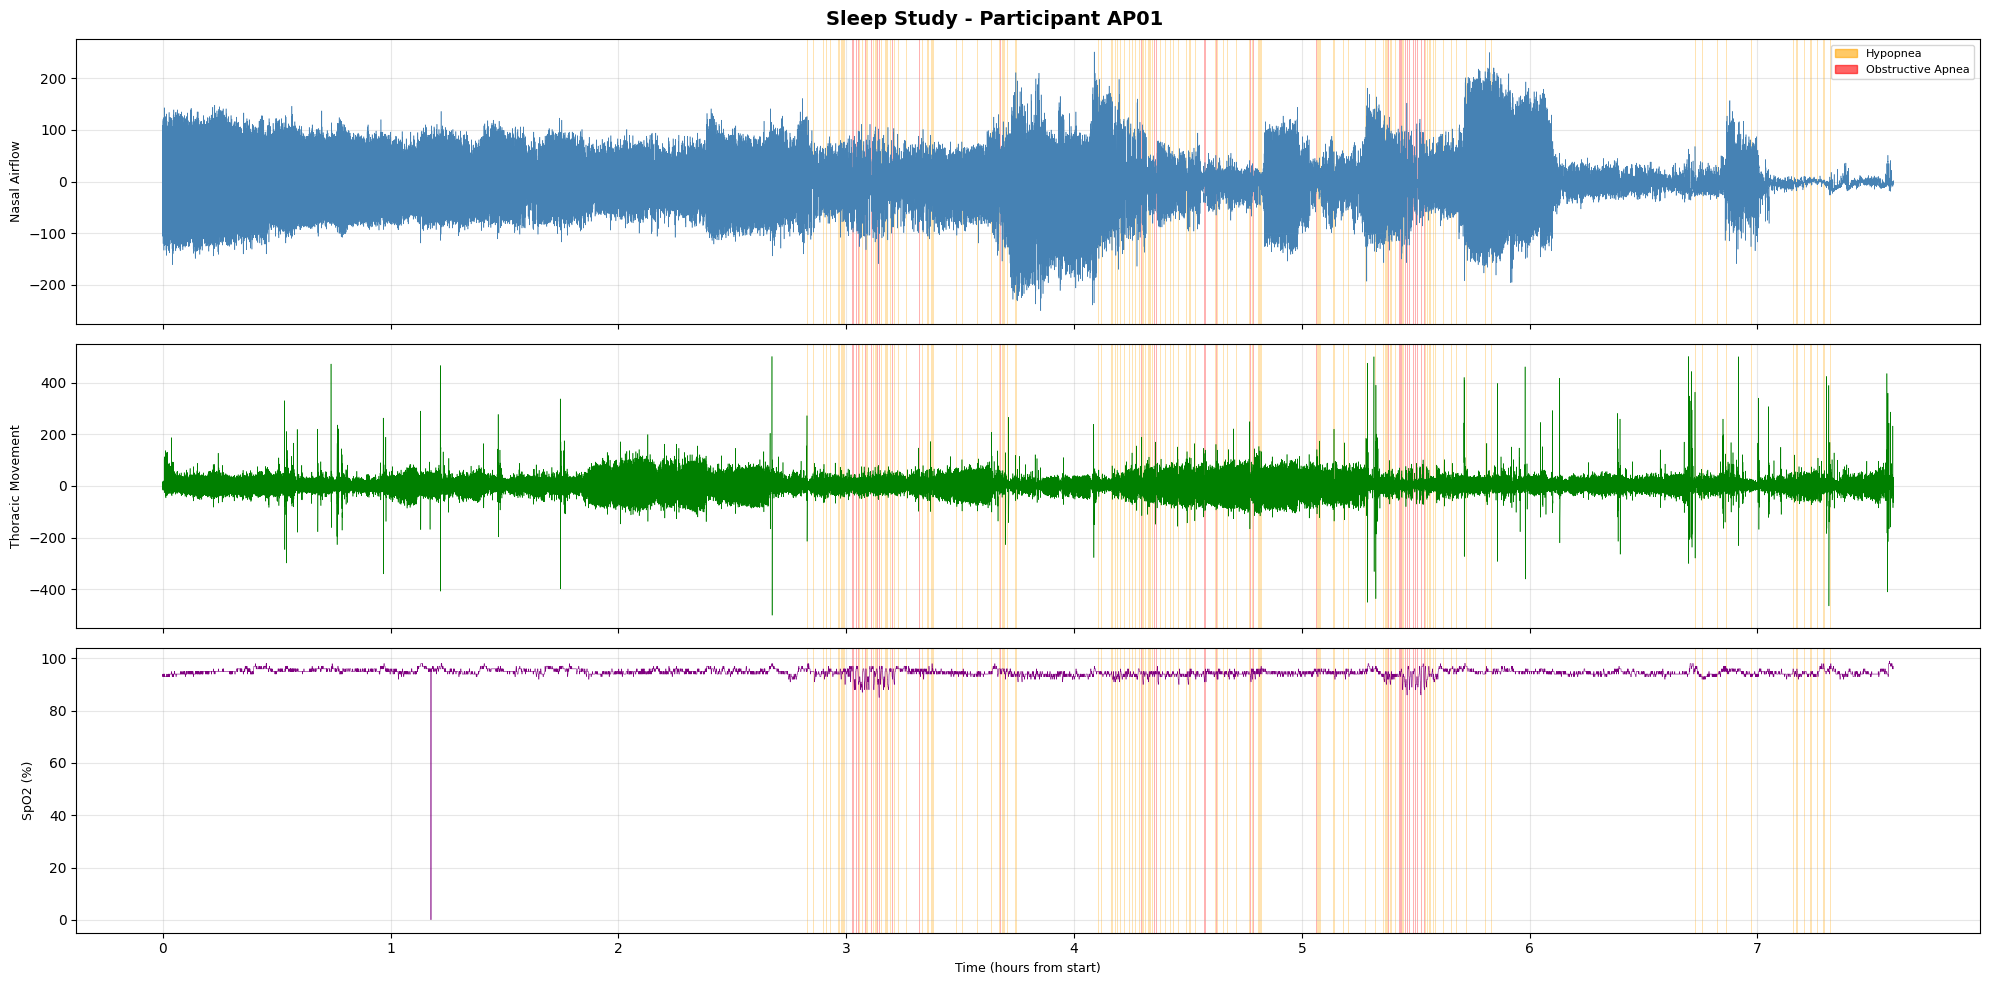

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

t0 = flow_df.index[0]

def to_hours(df):
    return (df.index - t0).total_seconds() / 3600

fig, axes = plt.subplots(3, 1, figsize=(20, 10), sharex=True)
fig.suptitle('Sleep Study - Participant AP01', fontsize=14, fontweight='bold')

signals = [
    (axes[0], to_hours(flow_df),   flow_df['value'],   'Nasal Airflow',     'steelblue'),
    (axes[1], to_hours(thorac_df), thorac_df['value'], 'Thoracic Movement', 'green'),
    (axes[2], to_hours(spo2_df),   spo2_df['value'],   'SpO2 (%)',          'purple'),
]

event_colors = {'Hypopnea': 'orange', 'Obstructive Apnea': 'red'}

for ax, t, vals, ylabel, color in signals:
    ax.plot(t, vals, color=color, linewidth=0.4, rasterized=True)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, alpha=0.3)
    for ev in events:
        ev_start_h = (ev['start'] - t0).total_seconds() / 3600
        ev_end_h   = (ev['end']   - t0).total_seconds() / 3600
        c = event_colors.get(ev['label'], 'gray')
        ax.axvspan(ev_start_h, ev_end_h, alpha=0.3, color=c, linewidth=0)

axes[2].set_xlabel('Time (hours from start)', fontsize=9)
legend_patches = [mpatches.Patch(color=c, alpha=0.6, label=l) for l, c in event_colors.items()]
axes[0].legend(handles=legend_patches, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
import os
from matplotlib.backends.backend_pdf import PdfPages

os.makedirs('Visualizations', exist_ok=True)

with PdfPages('Visualizations/AP01_visualization.pdf') as pdf:
    pdf.savefig(fig, dpi=100, bbox_inches='tight')



In [ ]:
script = '''
import os
import argparse
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages

def parse_signal_file(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    data_start = next(i for i, l in enumerate(lines) if l.strip() == 'Data:') + 1
    rows = []
    for line in lines[data_start:]:
        line = line.strip()
        if not line:
            continue
        ts_part, val_part = line.split(';')
        ts_part = ts_part.strip().replace(',', '.')
        timestamp = pd.to_datetime(ts_part, format='%d.%m.%Y %H:%M:%S.%f')
        rows.append((timestamp, float(val_part.strip())))
    df = pd.DataFrame(rows, columns=['timestamp', 'value'])
    df.set_index('timestamp', inplace=True)
    return df

def parse_events_file(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    events = []
    for line in lines:
        line = line.strip()
        if not line or ';' not in line or '-' not in line.split(';')[0]:
            continue
        try:
            date_range, duration, label, *_ = line.split(';')
            date_part, time_range = date_range.strip().split(' ')
            t_start_str, t_end_str = time_range.split('-')
            start_dt = pd.to_datetime(date_part + ' ' + t_start_str.replace(',', '.'),
                                      format='%d.%m.%Y %H:%M:%S.%f')
            end_dt = pd.to_datetime(date_part + ' ' + t_end_str.replace(',', '.'),
                                    format='%d.%m.%Y %H:%M:%S.%f')
            if end_dt < start_dt:
                end_dt += pd.Timedelta(days=1)
            events.append({'start': start_dt, 'end': end_dt, 'label': label.strip()})
        except Exception:
            continue
    return events

def find_file(folder, keyword):
    for f in os.listdir(folder):
        if keyword.lower() in f.lower():
            return os.path.join(folder, f)
    raise FileNotFoundError(f"No file with keyword '{keyword}' in {folder}")

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('-name', required=True)
    args = parser.parse_args()

    folder = args.name
    participant_id = os.path.basename(folder)
    out_dir = 'Visualizations'
    os.makedirs(out_dir, exist_ok=True)

    print(f"Loading signals for {participant_id}...")
    flow_df   = parse_signal_file(find_file(folder, 'Flow -'))
    thorac_df = parse_signal_file(find_file(folder, 'Thorac'))
    spo2_df   = parse_signal_file(find_file(folder, 'SPO2'))
    events    = parse_events_file(find_file(folder, 'Flow Events'))

    t0 = flow_df.index[0]
    def to_hours(df):
        return (df.index - t0).total_seconds() / 3600

    event_colors = {'Hypopnea': 'orange', 'Obstructive Apnea': 'red'}

    fig, axes = plt.subplots(3, 1, figsize=(20, 10), sharex=True)
    fig.suptitle(f'Sleep Study - Participant {participant_id}', fontsize=14, fontweight='bold')

    signals = [
        (axes[0], to_hours(flow_df),   flow_df['value'],   'Nasal Airflow',     'steelblue'),
        (axes[1], to_hours(thorac_df), thorac_df['value'], 'Thoracic Movement', 'green'),
        (axes[2], to_hours(spo2_df),   spo2_df['value'],   'SpO2 (%)',          'purple'),
    ]

    for ax, t, vals, ylabel, color in signals:
        ax.plot(t, vals, color=color, linewidth=0.4, rasterized=True)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.grid(True, alpha=0.3)
        for ev in events:
            ev_start_h = (ev['start'] - t0).total_seconds() / 3600
            ev_end_h   = (ev['end']   - t0).total_seconds() / 3600
            c = event_colors.get(ev['label'], 'gray')
            ax.axvspan(ev_start_h, ev_end_h, alpha=0.3, color=c, linewidth=0)

    axes[2].set_xlabel('Time (hours from start)', fontsize=9)
    legend_patches = [mpatches.Patch(color=c, alpha=0.6, label=l) for l, c in event_colors.items()]
    axes[0].legend(handles=legend_patches, loc='upper right', fontsize=8)
    plt.tight_layout()

    out_path = os.path.join(out_dir, f'{participant_id}_visualization.pdf')
    with PdfPages(out_path) as pdf:
        pdf.savefig(fig, dpi=100, bbox_inches='tight')
    plt.close()
    print(f"Saved: {out_path}")

if __name__ == '__main__':
    main()
'''

with open('vis.py', 'w') as f:
    f.write(script)

print("vis.py created")

vis.py created


In [ ]:
!python vis.py -name "/content/drive/MyDrive/AP01"

Loading signals for AP01...
Saved: Visualizations/AP01_visualization.pdf


Part2- Signal Preprocessing and Dataset Creation

In [ ]:
from scipy.signal import butter, filtfilt
import numpy as np

def bandpass_filter(signal, lowcut=0.17, highcut=0.4, fs=32, order=4):
    nyq = fs / 2
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

# Test on flow signal
flow_filtered = bandpass_filter(flow_df['value'].values, fs=32)
print("Original Flow - min:", flow_df['value'].min(), "max:", flow_df['value'].max())
print("Filtered Flow - min:", flow_filtered.min(), "max:", flow_filtered.max())

Original Flow - min: -250.0 max: 251.0
Filtered Flow - min: -231.16169130624144 max: 228.61990954765105


In [ ]:
# Filter all 3 signals
flow_filtered   = bandpass_filter(flow_df['value'].values, fs=32)
thorac_filtered = bandpass_filter(thorac_df['value'].values, fs=32)
spo2_filtered   = bandpass_filter(spo2_df['value'].values, fs=4)

print("Flow filtered shape:", flow_filtered.shape)
print("Thorac filtered shape:", thorac_filtered.shape)
print("SpO2 filtered shape:", spo2_filtered.shape)

Flow filtered shape: (875184,)
Thorac filtered shape: (875184,)
SpO2 filtered shape: (109398,)


In [ ]:
def create_windows(signal, fs, window_sec=30, overlap=0.5):
    window_size = int(window_sec * fs)
    step_size   = int(window_size * (1 - overlap))
    windows = []
    starts  = []
    for start in range(0, len(signal) - window_size + 1, step_size):
        windows.append(signal[start:start + window_size])
        starts.append(start)
    return np.array(windows), starts

# Create windows for all signals
flow_windows,   flow_starts   = create_windows(flow_filtered,   fs=32)
thorac_windows, thorac_starts = create_windows(thorac_filtered, fs=32)
spo2_windows,   spo2_starts   = create_windows(spo2_filtered,   fs=4)

print("Flow windows shape:",   flow_windows.shape)
print("Thorac windows shape:", thorac_windows.shape)
print("SpO2 windows shape:",   spo2_windows.shape)

Flow windows shape: (1822, 960)
Thorac windows shape: (1822, 960)
SpO2 windows shape: (1822, 120)


In [ ]:
def label_windows(starts, fs, t0, events, window_sec=30):
    labels = []
    window_duration = pd.Timedelta(seconds=window_sec)

    for start_idx in starts:
        win_start = t0 + pd.Timedelta(seconds=start_idx / fs)
        win_end   = win_start + window_duration

        label = 'Normal'
        for ev in events:
            # Calculate overlap between window and event
            overlap_start = max(win_start, ev['start'])
            overlap_end   = min(win_end,   ev['end'])
            overlap_sec   = (overlap_end - overlap_start).total_seconds()

            if overlap_sec > 0.5 * window_sec:
                label = ev['label']
                break
        labels.append(label)
    return labels

t0 = flow_df.index[0]
labels = label_windows(flow_starts, fs=32, t0=t0, events=events)

import pandas as pd
print("Label counts:")
print(pd.Series(labels).value_counts())

Label counts:
Normal               1727
Hypopnea               79
Obstructive Apnea      16
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np

rows = []
for i in range(len(flow_windows)):
    rows.append({
        'participant': 'AP01',
        'window_idx':  i,
        'flow':        flow_windows[i],
        'thorac':      thorac_windows[i],
        'spo2':        spo2_windows[i],
        'label':       labels[i]
    })

dataset_df = pd.DataFrame(rows)
print(dataset_df.shape)
print(dataset_df.head(3))
print("\nLabel distribution:")
print(dataset_df['label'].value_counts())

(1822, 6)
  participant  window_idx                                               flow  \
0        AP01           0  [35.79589475300924, 34.51643935193731, 33.0870...   
1        AP01           1  [101.79798806330602, 106.20436874110517, 110.3...   
2        AP01           2  [-69.52902468045042, -75.03650915370152, -80.2...   

                                              thorac  \
0  [7.090939814271049, 7.28229806505017, 7.454058...   
1  [3.3070819237407028, 4.119591930008364, 4.9209...   
2  [-1.0672884119494013, -1.7746894291620938, -2....   

                                                spo2   label  
0  [0.0020111943838420836, 0.22929201245943967, 0...  Normal  
1  [-0.26623140547379276, -0.21257758462489193, -...  Normal  
2  [-0.03663661195773241, -0.15660171297951256, -...  Normal  

Label distribution:
label
Normal               1727
Hypopnea               79
Obstructive Apnea      16
Name: count, dtype: int64


In [ ]:
import os

os.makedirs('Dataset', exist_ok=True)
dataset_df.to_pickle('Dataset/AP01_dataset.pkl')
print("Saved: Dataset/AP01_dataset.pkl")
print("File size:", round(os.path.getsize('Dataset/AP01_dataset.pkl') / 1024 / 1024, 2), "MB")

Saved: Dataset/AP01_dataset.pkl
File size: 28.52 MB


In [ ]:
import os

base = "/content/drive/MyDrive/Data"
participants = sorted([f for f in os.listdir(base)
                       if os.path.isdir(os.path.join(base, f))])
print(participants)

['AP01', 'AP02', 'AP03', 'AP04', 'AP05']


In [ ]:
def find_file(folder, keyword):
    keyword_lower = keyword.lower().strip()
    matches = []
    for f in os.listdir(folder):
        f_lower = f.lower().strip()
        if keyword_lower in f_lower:
            # Exclude 'flow events' when searching for plain 'flow'
            if keyword_lower == 'flow' and 'events' in f_lower:
                continue
            matches.append(f)
    if matches:
        return os.path.join(folder, sorted(matches, key=len)[0])
    raise FileNotFoundError(f"No file with keyword '{keyword}' in {folder}")

# Test all 5
keywords = ['flow events', 'flow', 'spo2', 'thorac', 'sleep profile']
for pid in ['AP01', 'AP02', 'AP03', 'AP04', 'AP05']:
    folder = os.path.join(base, pid)
    print(f"\n{pid}:")
    for kw in keywords:
        try:
            print(f"  {kw} -> {os.path.basename(find_file(folder, kw))}")
        except FileNotFoundError as e:
            print(f"  ERROR: {e}")


AP01:
  flow events -> Flow Events - 30-05-2024.txt
  flow -> Flow - 30-05-2024.txt
  spo2 -> SPO2 - 30-05-2024.txt
  thorac -> Thorac - 30-05-2024.txt
  sleep profile -> Sleep profile - 30-05-2024.txt

AP02:
  flow events -> Flow Events  - 30.05.2024.txt
  flow -> Flow  - 30.05.2024.txt
  spo2 -> SPO2  - 30.05.2024.txt
  thorac -> Thorac  - 30.05.2024.txt
  sleep profile -> Sleep profile  - 30.05.2024.txt

AP03:
  flow events -> Flow Events - 29_05_2024.txt
  flow -> Flow - 29_05_2024.txt
  spo2 -> SPO2 - 29_05_2024.txt
  thorac -> Thorac - 29_05_2024.txt
  sleep profile -> Sleep profile - 29_05_2024.txt

AP04:
  flow events -> Flow Events - 29.05.2024.txt
  flow -> Flow Signal - 29.05.2024.txt
  spo2 -> SPO2 Signal - 29.05.2024.txt
  thorac -> Thorac Signal - 29.05.2024.txt
  sleep profile -> Sleep profile - 29.05.2024.txt

AP05:
  flow events -> Flow Events - 28.05.2024.txt
  flow -> Flow Nasal - 28.05.2024.txt
  spo2 -> SPO2 - 28.05.2024.txt
  thorac -> Thorac Movement - 28.05.202

In [ ]:
all_data = []

for pid in ['AP01', 'AP02', 'AP03', 'AP04', 'AP05']:
    folder = os.path.join(base, pid)
    print(f"Processing {pid}...")

    flow_df   = parse_signal_file(find_file(folder, 'flow'))
    thorac_df = parse_signal_file(find_file(folder, 'thorac'))
    spo2_df   = parse_signal_file(find_file(folder, 'spo2'))
    events    = parse_events_file(find_file(folder, 'flow events'))

    flow_f   = bandpass_filter(flow_df['value'].values,   fs=32)
    thorac_f = bandpass_filter(thorac_df['value'].values, fs=32)
    spo2_f   = bandpass_filter(spo2_df['value'].values,   fs=4)

    flow_win,   flow_starts = create_windows(flow_f,   fs=32)
    thorac_win, _           = create_windows(thorac_f, fs=32)
    spo2_win,   _           = create_windows(spo2_f,   fs=4)

    t0     = flow_df.index[0]
    labels = label_windows(flow_starts, fs=32, t0=t0, events=events)

    for i in range(len(flow_win)):
        all_data.append({
            'participant': pid,
            'window_idx':  i,
            'flow':        flow_win[i],
            'thorac':      thorac_win[i],
            'spo2':        spo2_win[i],
            'label':       labels[i]
        })

    print(f"  {pid} done — {len(flow_win)} windows | {pd.Series(labels).value_counts().to_dict()}")

full_df = pd.DataFrame(all_data)
full_df.to_pickle('Dataset/full_dataset.pkl')
print(f"\nTotal windows: {len(full_df)}")
print(full_df['label'].value_counts())
print("\nSaved: Dataset/full_dataset.pkl")

Processing AP01...
  AP01 done — 1822 windows | {'Normal': 1727, 'Hypopnea': 79, 'Obstructive Apnea': 16}
Processing AP02...
  AP02 done — 1769 windows | {'Normal': 1616, 'Hypopnea': 150, 'Obstructive Apnea': 3}
Processing AP03...
  AP03 done — 1696 windows | {'Normal': 1679, 'Hypopnea': 16, 'Obstructive Apnea': 1}
Processing AP04...
  AP04 done — 1932 windows | {'Normal': 1763, 'Hypopnea': 166, 'Body event': 2, 'Obstructive Apnea': 1}
Processing AP05...
  AP05 done — 1581 windows | {'Normal': 1256, 'Hypopnea': 182, 'Obstructive Apnea': 140, 'Mixed Apnea': 2, 'Body event': 1}

Total windows: 8800
label
Normal               8041
Hypopnea              593
Obstructive Apnea     161
Body event              3
Mixed Apnea             2
Name: count, dtype: int64

Saved: Dataset/full_dataset.pkl


In [ ]:
#After cleaning, we remove ambiguous labels and keep only 3 clean classes for modeling.
full_df['label'] = full_df['label'].replace('Mixed Apnea', 'Obstructive Apnea')
full_df = full_df[full_df['label'] != 'Body event'].reset_index(drop=True)

print("After cleaning:")
print(full_df['label'].value_counts())
print("Total windows:", len(full_df))

After cleaning:
label
Normal               8041
Hypopnea              593
Obstructive Apnea     163
Name: count, dtype: int64
Total windows: 8797


In [ ]:
# Save the cleaned dataset to pickle
full_df.to_pickle('Dataset/full_dataset.pkl')
print("Saved cleaned dataset: Dataset/full_dataset.pkl")
print("Total windows:", len(full_df))

Saved cleaned dataset: Dataset/full_dataset.pkl
Total windows: 8797


In [ ]:
script = '''
import os
import argparse
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt

def parse_signal_file(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    data_start = next(i for i, l in enumerate(lines) if l.strip() == 'Data:') + 1
    rows = []
    for line in lines[data_start:]:
        line = line.strip()
        if not line:
            continue
        ts_part, val_part = line.split(';')
        ts_part = ts_part.strip().replace(',', '.')
        timestamp = pd.to_datetime(ts_part, format='%d.%m.%Y %H:%M:%S.%f')
        rows.append((timestamp, float(val_part.strip())))
    df = pd.DataFrame(rows, columns=['timestamp', 'value'])
    df.set_index('timestamp', inplace=True)
    return df

def parse_events_file(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    events = []
    for line in lines:
        line = line.strip()
        if not line or ';' not in line or '-' not in line.split(';')[0]:
            continue
        try:
            date_range, duration, label, *_ = line.split(';')
            date_part, time_range = date_range.strip().split(' ')
            t_start_str, t_end_str = time_range.split('-')
            start_dt = pd.to_datetime(date_part + ' ' + t_start_str.replace(',', '.'),
                                      format='%d.%m.%Y %H:%M:%S.%f')
            end_dt = pd.to_datetime(date_part + ' ' + t_end_str.replace(',', '.'),
                                    format='%d.%m.%Y %H:%M:%S.%f')
            if end_dt < start_dt:
                end_dt += pd.Timedelta(days=1)
            events.append({'start': start_dt, 'end': end_dt, 'label': label.strip()})
        except Exception:
            continue
    return events

def find_file(folder, keyword):
    keyword_lower = keyword.lower().strip()
    matches = []
    for f in os.listdir(folder):
        f_lower = f.lower().strip()
        if keyword_lower in f_lower:
            if keyword_lower == 'flow' and 'events' in f_lower:
                continue
            matches.append(f)
    if matches:
        return os.path.join(folder, sorted(matches, key=len)[0])
    raise FileNotFoundError(f"No file with keyword '{keyword}' in {folder}")

def bandpass_filter(signal, lowcut=0.17, highcut=0.4, fs=32, order=4):
    nyq  = fs / 2
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal)

def create_windows(signal, fs, window_sec=30, overlap=0.5):
    window_size = int(window_sec * fs)
    step_size   = int(window_size * (1 - overlap))
    windows, starts = [], []
    for start in range(0, len(signal) - window_size + 1, step_size):
        windows.append(signal[start:start + window_size])
        starts.append(start)
    return np.array(windows), starts

def label_windows(starts, fs, t0, events, window_sec=30):
    labels = []
    for start_idx in starts:
        win_start = t0 + pd.Timedelta(seconds=start_idx / fs)
        win_end   = win_start + pd.Timedelta(seconds=window_sec)
        label = 'Normal'
        for ev in events:
            overlap_sec = (min(win_end, ev['end']) - max(win_start, ev['start'])).total_seconds()
            if overlap_sec > 0.5 * window_sec:
                label = ev['label']
                break
        labels.append(label)
    return labels

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('-in_dir',  required=True)
    parser.add_argument('-out_dir', required=True)
    args = parser.parse_args()

    os.makedirs(args.out_dir, exist_ok=True)
    participants = sorted([f for f in os.listdir(args.in_dir)
                           if os.path.isdir(os.path.join(args.in_dir, f))])
    all_data = []

    for pid in participants:
        folder = os.path.join(args.in_dir, pid)
        print(f"Processing {pid}...")

        flow_df   = parse_signal_file(find_file(folder, 'flow'))
        thorac_df = parse_signal_file(find_file(folder, 'thorac'))
        spo2_df   = parse_signal_file(find_file(folder, 'spo2'))
        events    = parse_events_file(find_file(folder, 'flow events'))

        flow_f   = bandpass_filter(flow_df['value'].values,   fs=32)
        thorac_f = bandpass_filter(thorac_df['value'].values, fs=32)
        spo2_f   = bandpass_filter(spo2_df['value'].values,   fs=4)

        flow_win,   flow_starts = create_windows(flow_f,   fs=32)
        thorac_win, _           = create_windows(thorac_f, fs=32)
        spo2_win,   _           = create_windows(spo2_f,   fs=4)

        t0     = flow_df.index[0]
        labels = label_windows(flow_starts, fs=32, t0=t0, events=events)

        for i in range(len(flow_win)):
            all_data.append({
                'participant': pid,
                'window_idx':  i,
                'flow':        flow_win[i],
                'thorac':      thorac_win[i],
                'spo2':        spo2_win[i],
                'label':       labels[i]
            })

        print(f"  {pid} done — {len(flow_win)} windows | {pd.Series(labels).value_counts().to_dict()}")

    full_df = pd.DataFrame(all_data)
    full_df['label'] = full_df['label'].replace('Mixed Apnea', 'Obstructive Apnea')
    full_df = full_df[full_df['label'] != 'Body event'].reset_index(drop=True)

    out_path = os.path.join(args.out_dir, 'full_dataset.pkl')
    full_df.to_pickle(out_path)
    print(f"\\nTotal windows: {len(full_df)}")
    print(full_df['label'].value_counts())
    print(f"Saved: {out_path}")

if __name__ == '__main__':
    main()
'''

with open('create_dataset.py', 'w') as f:
    f.write(script)
print("create_dataset.py created")

create_dataset.py created


In [ ]:
!python create_dataset.py -in_dir "/content/drive/MyDrive/Data" -out_dir "Dataset"

Processing AP01...
  AP01 done — 1822 windows | {'Normal': 1727, 'Hypopnea': 79, 'Obstructive Apnea': 16}
Processing AP02...
  AP02 done — 1769 windows | {'Normal': 1616, 'Hypopnea': 150, 'Obstructive Apnea': 3}
Processing AP03...
  AP03 done — 1696 windows | {'Normal': 1679, 'Hypopnea': 16, 'Obstructive Apnea': 1}
Processing AP04...
  AP04 done — 1932 windows | {'Normal': 1763, 'Hypopnea': 166, 'Body event': 2, 'Obstructive Apnea': 1}
Processing AP05...
  AP05 done — 1581 windows | {'Normal': 1256, 'Hypopnea': 182, 'Obstructive Apnea': 140, 'Mixed Apnea': 2, 'Body event': 1}

Total windows: 8797
label
Normal               8041
Hypopnea              593
Obstructive Apnea     163
Name: count, dtype: int64
Saved: Dataset/full_dataset.pkl


Part3-Basic Modeling and Evaluation

In [ ]:
import pandas as pd

# Loading the saved dataset from Part 2
full_df = pd.read_pickle('Dataset/full_dataset.pkl')

print("Shape:", full_df.shape)
print("\nColumns:", full_df.columns.tolist())
print("\nParticipants:", full_df['participant'].unique())
print("\nLabel counts:")
print(full_df['label'].value_counts())

Shape: (8797, 6)

Columns: ['participant', 'window_idx', 'flow', 'thorac', 'spo2', 'label']

Participants: ['AP01' 'AP02' 'AP03' 'AP04' 'AP05']

Label counts:
label
Normal               8041
Hypopnea              593
Obstructive Apnea     163
Name: count, dtype: int64


In [ ]:
import numpy as np
from scipy.signal import resample

# Stack all 3 signals as channels per window — shape will be (8797, 960, 3)
X, y, participants = [], [], []

for _, row in full_df.iterrows():
    flow   = row['flow']
    thorac = row['thorac']
    spo2   = resample(row['spo2'], 960)  # upsample spo2 from 120 to 960

    window = np.stack([flow, thorac, spo2], axis=1)  # shape (960, 3)
    X.append(window)
    y.append(row['label'])
    participants.append(row['participant'])

X            = np.array(X)
participants = np.array(participants)

print("X shape:", X.shape)
print("Sample labels:", y[:5])

X shape: (8797, 960, 3)
Sample labels: ['Normal', 'Normal', 'Normal', 'Normal', 'Normal']


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Convert text labels to numbers: Normal=0, Hypopnea=1, Obstructive Apnea=2
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} -> {cls}")

print("\ny_encoded sample:", y_encoded[:5])
print("Unique values:", np.unique(y_encoded))

Label mapping:
  0 -> Hypopnea
  1 -> Normal
  2 -> Obstructive Apnea

y_encoded sample: [1 1 1 1 1]
Unique values: [0 1 2]


In [ ]:
#A simple CNN that takes 960 timepoints × 3 channels as input and outputs 3 class probabilities.
import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn(input_shape=(960, 3), num_classes=3):
    model = models.Sequential([
        # First conv block — extract low level features
        layers.Conv1D(32, kernel_size=5, activation='relu', input_shape=input_shape),
        layers.MaxPooling1D(pool_size=2),

        # Second conv block — extract higher level features
        layers.Conv1D(64, kernel_size=5, activation='relu'),
        layers.MaxPooling1D(pool_size=2),

        # Third conv block
        layers.Conv1D(128, kernel_size=3, activation='relu'),
        layers.GlobalAveragePooling1D(),

        # Fully connected layers
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Test model builds correctly
model = build_cnn()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 956, 32)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 478, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 474, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 237, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 235, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,971 (171.76 KB)

 Trainable params: 43,971 (171.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import numpy as np

participants_list = ['AP01', 'AP02', 'AP03', 'AP04', 'AP05']
all_results = []

for test_pid in participants_list:
    print(f"\nFold: Test on {test_pid}")

    # Split into train and test
    test_mask  = participants == test_pid
    train_mask = ~test_mask

    X_train, y_train = X[train_mask], y_encoded[train_mask]
    X_test,  y_test  = X[test_mask],  y_encoded[test_mask]

    print(f"  Train: {X_train.shape[0]} windows | Test: {X_test.shape[0]} windows")

    # Build and train fresh model for each fold
    model = build_cnn()
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

    # Predict
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)

    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  Confusion Matrix:\n{cm}")

    all_results.append({'participant': test_pid, 'accuracy': acc,
                        'precision': prec, 'recall': rec, 'cm': cm})


Fold: Test on AP01
  Train: 6975 windows | Test: 1822 windows


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Accuracy:  0.9479
  Precision: 0.3160
  Recall:    0.3333
  Confusion Matrix:
[[   0   79    0]
 [   0 1727    0]
 [   0   16    0]]

Fold: Test on AP02
  Train: 7028 windows | Test: 1769 windows


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Accuracy:  0.9135
  Precision: 0.3045
  Recall:    0.3333
  Confusion Matrix:
[[   0  150    0]
 [   0 1616    0]
 [   0    3    0]]

Fold: Test on AP03
  Train: 7101 windows | Test: 1696 windows


...

  Accuracy:  0.9900
  Precision: 0.3300
  Recall:    0.3333
  Confusion Matrix:
[[   0   16    0]
 [   0 1679    0]
 [   0    1    0]]

Fold: Test on AP04
  Train: 6867 windows | Test: 1930 windows


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Accuracy:  0.9135
  Precision: 0.3045
  Recall:    0.3333
  Confusion Matrix:
[[   0  166    0]
 [   0 1763    0]
 [   0    1    0]]

Fold: Test on AP05
  Train: 7217 windows | Test: 1580 windows


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Accuracy:  0.7949
  Precision: 0.2650
  Recall:    0.3333
  Confusion Matrix:
[[   0  182    0]
 [   0 1256    0]
 [   0  142    0]]


This is because of severe class imbalance — 8041 Normal vs 756 abnormal
The model learned "always predict Normal" to get high accuracy.
Fix — add class weights to penalize the model more for missing Hypopnea and Apnea cases:

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

participants_list = ['AP01', 'AP02', 'AP03', 'AP04', 'AP05']
all_results = []

for test_pid in participants_list:
    print(f"\nFold: Test on {test_pid}")

    test_mask  = participants == test_pid
    train_mask = ~test_mask

    X_train, y_train = X[train_mask], y_encoded[train_mask]
    X_test,  y_test  = X[test_mask],  y_encoded[test_mask]

    # Compute class weights to handle imbalance
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weight_dict = dict(enumerate(class_weights))
    print(f"  Class weights: {class_weight_dict}")

    model = build_cnn()
    model.fit(X_train, y_train, epochs=15, batch_size=32,
              class_weight=class_weight_dict, verbose=0)

    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)

    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  Confusion Matrix:\n{cm}")

    all_results.append({'participant': test_pid, 'accuracy': acc,
                        'precision': prec, 'recall': rec, 'cm': cm})


Fold: Test on AP01
  Class weights: {0: np.float64(4.523346303501945), 1: np.float64(0.36822933164396576), 2: np.float64(15.816326530612244)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Accuracy:  0.3112
  Precision: 0.3627
  Recall:    0.5287
  Confusion Matrix:
[[  58   11   10]
 [1100  500  127]
 [   6    1    9]]

Fold: Test on AP02
  Class weights: {0: np.float64(5.288186606471031), 1: np.float64(0.36461738002594035), 2: np.float64(14.641666666666667)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Accuracy:  0.7733
  Precision: 0.3755
  Recall:    0.5927
  Confusion Matrix:
[[  44   86   20]
 [ 218 1322   76]
 [   0    1    2]]

Fold: Test on AP03
  Class weights: {0: np.float64(4.102253032928942), 1: np.float64(0.372052813580635), 2: np.float64(14.61111111111111)}


...

  Accuracy:  0.1055
  Precision: 0.3319
  Recall:    0.4099
  Confusion Matrix:
[[   2    2   12]
 [ 332  176 1171]
 [   0    0    1]]

Fold: Test on AP04
  Class weights: {0: np.float64(5.360655737704918), 1: np.float64(0.364606562599554), 2: np.float64(14.12962962962963)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Accuracy:  0.6689
  Precision: 0.3379
  Recall:    0.3223
  Confusion Matrix:
[[  43  115    8]
 [ 394 1248  121]
 [   1    0    0]]

Fold: Test on AP05
  Class weights: {0: np.float64(5.853203568532035), 1: np.float64(0.3545566199950872), 2: np.float64(114.55555555555556)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Accuracy:  0.3247
  Precision: 0.4059
  Recall:    0.4476
  Confusion Matrix:
[[ 34  29 119]
 [142 355 759]
 [ 14   4 124]]


The inconsistency is because:
AP01, AP03 have very few abnormal events (16 Hypopnea, 1 Apnea) — model struggles to generalize to these participants.
AP05 has extreme class weight (114x) for Obstructive Apnea — model gets confused.

In [ ]:
print("="*55)
print(f"{'Participant':<15} {'Accuracy':<12} {'Precision':<12} {'Recall':<12}")
print("="*55)

accs, precs, recs = [], [], []
for r in all_results:
    print(f"{r['participant']:<15} {r['accuracy']:<12.4f} {r['precision']:<12.4f} {r['recall']:<12.4f}")
    accs.append(r['accuracy'])
    precs.append(r['precision'])
    recs.append(r['recall'])

print("="*55)
print(f"{'Average':<15} {np.mean(accs):<12.4f} {np.mean(precs):<12.4f} {np.mean(recs):<12.4f}")

print("\nConfusion Matrices (0=Hypopnea, 1=Normal, 2=Obstructive Apnea):")
for r in all_results:
    print(f"\n{r['participant']}:")
    print(r['cm'])

Participant     Accuracy     Precision    Recall      
AP01            0.3112       0.3627       0.5287      
AP02            0.7733       0.3755       0.5927      
AP03            0.1055       0.3319       0.4099      
AP04            0.6689       0.3379       0.3223      
AP05            0.3247       0.4059       0.4476      
Average         0.4367       0.3628       0.4602      

Confusion Matrices (0=Hypopnea, 1=Normal, 2=Obstructive Apnea):

AP01:
[[  58   11   10]
 [1100  500  127]
 [   6    1    9]]

AP02:
[[  44   86   20]
 [ 218 1322   76]
 [   0    1    2]]

AP03:
[[   2    2   12]
 [ 332  176 1171]
 [   0    0    1]]

AP04:
[[  43  115    8]
 [ 394 1248  121]
 [   1    0    0]]

AP05:
[[ 34  29 119]
 [142 355 759]
 [ 14   4 124]]


In [ ]:
def build_cnn(input_shape=(960, 3), num_classes=3):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv1D(32, kernel_size=5, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(64, kernel_size=5, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(128, kernel_size=3, activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),

        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Re-run Leave-One-Out with improved model
all_results = []

for test_pid in participants_list:
    print(f"\nFold: Test on {test_pid}")

    test_mask  = participants == test_pid
    train_mask = ~test_mask

    X_train, y_train = X[train_mask], y_encoded[train_mask]
    X_test,  y_test  = X[test_mask],  y_encoded[test_mask]

    class_weights    = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weight_dict = dict(enumerate(class_weights))

    model = build_cnn()
    model.fit(X_train, y_train, epochs=30, batch_size=32,
              class_weight=class_weight_dict, verbose=0)

    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)

    print(f"  Accuracy:  {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}")
    print(f"  Confusion Matrix:\n{cm}")

    all_results.append({'participant': test_pid, 'accuracy': acc,
                        'precision': prec, 'recall': rec, 'cm': cm})


Fold: Test on AP01
  Accuracy:  0.4292 | Precision: 0.3668 | Recall: 0.6206
  Confusion Matrix:
[[ 50  13  16]
 [825 719 183]
 [  3   0  13]]

Fold: Test on AP02
  Accuracy:  0.7575 | Precision: 0.3850 | Recall: 0.6212
  Confusion Matrix:
[[  61   77   12]
 [ 312 1277   27]
 [   1    0    2]]

Fold: Test on AP03
  Accuracy:  0.1374 | Precision: 0.3308 | Recall: 0.3794
  Confusion Matrix:
[[   0    2   14]
 [ 211  232 1236]
 [   0    0    1]]

Fold: Test on AP04
  Accuracy:  0.7969 | Precision: 0.3544 | Recall: 0.3672
  Confusion Matrix:
[[  42  123    1]
 [ 259 1496    8]
 [   1    0    0]]

Fold: Test on AP05
  Accuracy:  0.4304 | Precision: 0.4002 | Recall: 0.4924
  Confusion Matrix:
[[ 41  42  99]
 [345 520 391]
 [  8  15 119]]


In [ ]:
print("="*55)
print(f"{'Participant':<15} {'Accuracy':<12} {'Precision':<12} {'Recall':<12}")
print("="*55)

accs, precs, recs = [], [], []
for r in all_results:
    print(f"{r['participant']:<15} {r['accuracy']:<12.4f} {r['precision']:<12.4f} {r['recall']:<12.4f}")
    accs.append(r['accuracy'])
    precs.append(r['precision'])
    recs.append(r['recall'])

print("="*55)
print(f"{'Average':<15} {np.mean(accs):<12.4f} {np.mean(precs):<12.4f} {np.mean(recs):<12.4f}")

print("\nConfusion Matrices (0=Hypopnea, 1=Normal, 2=Obstructive Apnea):")
for r in all_results:
    print(f"\n{r['participant']}:")
    print(r['cm'])

Participant     Accuracy     Precision    Recall      
AP01            0.4292       0.3668       0.6206      
AP02            0.7575       0.3850       0.6212      
AP03            0.1374       0.3308       0.3794      
AP04            0.7969       0.3544       0.3672      
AP05            0.4304       0.4002       0.4924      
Average         0.5103       0.3674       0.4962      

Confusion Matrices (0=Hypopnea, 1=Normal, 2=Obstructive Apnea):

AP01:
[[ 50  13  16]
 [825 719 183]
 [  3   0  13]]

AP02:
[[  61   77   12]
 [ 312 1277   27]
 [   1    0    2]]

AP03:
[[   0    2   14]
 [ 211  232 1236]
 [   0    0    1]]

AP04:
[[  42  123    1]
 [ 259 1496    8]
 [   1    0    0]]

AP05:
[[ 41  42  99]
 [345 520 391]
 [  8  15 119]]


AP03 is the outlier — it only had 16 Hypopnea + 1 Apnea windows total, making it nearly impossible to generalize to.

In [ ]:
# Save each window's signals as flattened rows in CSV
flat_df = full_df[['participant', 'window_idx', 'label']].copy()
flat_df.to_csv('Dataset/breathing_dataset.csv', index=False)
print("Saved: Dataset/breathing_dataset.csv")

Saved: Dataset/breathing_dataset.csv


In [ ]:
script = '''
import os
import numpy as np
import pandas as pd
from scipy.signal import resample
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from cnn_model import build_cnn

# Load dataset
print("Loading dataset...")
full_df = pd.read_pickle("Dataset/full_dataset.pkl")

# Prepare input features — stack 3 signals as channels
print("Preparing features...")
X, y, participants = [], [], []
for _, row in full_df.iterrows():
    flow   = row["flow"]
    thorac = row["thorac"]
    spo2   = resample(row["spo2"], 960)
    window = np.stack([flow, thorac, spo2], axis=1)
    X.append(window)
    y.append(row["label"])
    participants.append(row["participant"])

X            = np.array(X)
participants = np.array(participants)

# Encode labels
le        = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# Leave-One-Participant-Out Cross Validation
participants_list = sorted(full_df["participant"].unique())
all_results = []

for test_pid in participants_list:
    print(f"\\nFold: Test on {test_pid}")

    test_mask  = participants == test_pid
    train_mask = ~test_mask

    X_train, y_train = X[train_mask], y_encoded[train_mask]
    X_test,  y_test  = X[test_mask],  y_encoded[test_mask]

    print(f"  Train: {X_train.shape[0]} windows | Test: {X_test.shape[0]} windows")

    class_weights     = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
    class_weight_dict = dict(enumerate(class_weights))

    model = build_cnn()
    model.fit(X_train, y_train, epochs=20, batch_size=64,
              class_weight=class_weight_dict, verbose=0)

    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="macro", zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)

    print(f"  Accuracy:  {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}")
    print(f"  Confusion Matrix:\\n{cm}")

    all_results.append({"participant": test_pid, "accuracy": acc,
                        "precision": prec, "recall": rec, "cm": cm})

# Final summary
print("\\n" + "="*55)
print(f"{"Participant":<15} {"Accuracy":<12} {"Precision":<12} {"Recall":<12}")
print("="*55)
accs, precs, recs = [], [], []
for r in all_results:
    print(f"{r["participant"]:<15} {r["accuracy"]:<12.4f} {r["precision"]:<12.4f} {r["recall"]:<12.4f}")
    accs.append(r["accuracy"])
    precs.append(r["precision"])
    recs.append(r["recall"])
print("="*55)
print(f"{"Average":<15} {np.mean(accs):<12.4f} {np.mean(precs):<12.4f} {np.mean(recs):<12.4f}")

print("\\nConfusion Matrices (0=Hypopnea, 1=Normal, 2=Obstructive Apnea):")
for r in all_results:
    print(f"\\n{r["participant"]}:")
    print(r["cm"])
'''

with open('train_model.py', 'w') as f:
    f.write(script)
print("train_model.py created")

train_model.py created


In [ ]:
script = """
import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn(input_shape=(960, 3), num_classes=3):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv1D(32, kernel_size=5, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(64, kernel_size=5, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(128, kernel_size=3, activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),

        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model
"""

with open('cnn_model.py', 'w') as f:
    f.write(script)
print("cnn_model.py created")

cnn_model.py created


In [ ]:
reqs = """numpy
pandas
scipy
matplotlib
scikit-learn
tensorflow
"""

with open('requirements.txt', 'w') as f:
    f.write(reqs)
print("requirements.txt created")

requirements.txt created
